# GTFS public transport

This notebook builds static public-transport `UrbanGraph` objects from GTFS Schedule feeds: it reads and validates a feed, selects a service day and time window, merges several feeds of one city, and joins the result to an OpenStreetMap walking network for routing.

The feeds are small synthetic examples placed on approximate coordinates in Saint Petersburg's Vasileostrovsky District, so the notebook runs without downloading a real feed. Replace the paths with your own GTFS directories or ZIP archives.

In [1]:
# To install IduEdu in a clean environment:
# !pip install IduEdu

OSM_ID = 1114252
SERVICE_DATE = "2026-09-14"  # a Monday

## Example feeds

Three agencies publish their own feed, and each of them numbers its only route `1`:

- **metro**: two stations with entrances, escalator pathways and boarding areas, a `frequencies.txt` service every 4 minutes, and route geometry in `shapes.txt`;
- **bus**: five stops along Sredny Prospekt with a scheduled departure every 10 minutes and no shapes;
- **trolleybus**: three stops with a scheduled departure every 12 minutes; its stop on Sredny Prospekt is about 10 m from the bus stop.

In [2]:
import tempfile
from pathlib import Path

import pandas as pd

FEEDS_DIR = Path(tempfile.mkdtemp(prefix="iduedu_gtfs_"))
WEEKDAYS = {
    "monday": 1, "tuesday": 1, "wednesday": 1, "thursday": 1, "friday": 1, "saturday": 0, "sunday": 0,
}


def write_feed(name, **tables):
    """Write GTFS tables given as lists of rows to FEEDS_DIR / name."""
    folder = FEEDS_DIR / name
    folder.mkdir(parents=True, exist_ok=True)
    for table, rows in tables.items():
        pd.DataFrame(rows).to_csv(folder / f"{table}.txt", index=False)
    return folder


def agency_and_calendar(agency_name):
    return {
        "agency": [
            {"agency_id": "A", "agency_name": agency_name, "agency_url": "https://example.org", "agency_timezone": "Europe/Moscow"}
        ],
        "calendar": [{"service_id": "weekdays", **WEEKDAYS, "start_date": "20260101", "end_date": "20261231"}],
    }


def clock(minutes):
    return f"{minutes // 60:02d}:{minutes % 60:02d}:00"


def scheduled_trips(stop_ids, run_minutes, first, last, headway):
    """Trips in both directions, leaving every `headway` minutes between `first` and `last` (minutes after midnight)."""
    trips, stop_times = [], []
    for direction, (stops, runs) in enumerate([(stop_ids, run_minutes), (stop_ids[::-1], run_minutes[::-1])]):
        for departure in range(first, last, headway):
            trip_id = f"{direction}-{clock(departure)[:5]}"
            trips.append({"route_id": "1", "service_id": "weekdays", "trip_id": trip_id, "direction_id": direction})
            minute = departure
            for sequence, stop_id in enumerate(stops):
                minute += runs[sequence - 1] if sequence else 0
                stop_times.append(
                    {"trip_id": trip_id, "arrival_time": clock(minute), "departure_time": clock(minute), "stop_id": stop_id, "stop_sequence": sequence + 1}
                )
    return trips, stop_times


def station(prefix, name, lat, lon):
    """A station with a platform, a boarding area on that platform, and a street entrance."""
    def near(d_lat, d_lon):
        return {"stop_lat": round(lat + d_lat, 6), "stop_lon": round(lon + d_lon, 6)}

    return [
        {"stop_id": prefix, "stop_name": name, **near(0, 0), "location_type": 1, "parent_station": ""},
        {"stop_id": f"{prefix}_P", "stop_name": f"{name} platform", **near(-0.00005, -0.00005), "location_type": 0, "parent_station": prefix},
        {"stop_id": f"{prefix}_BA", "stop_name": f"{name} boarding area", **near(-0.00004, -0.00002), "location_type": 4, "parent_station": f"{prefix}_P"},
        {"stop_id": f"{prefix}_E", "stop_name": f"{name} entrance", **near(-0.00040, 0.00050), "location_type": 2, "parent_station": prefix},
    ]


primorskaya = (59.94860, 30.23450)
vasileostrovskaya = (59.94270, 30.27830)
metro_shape = [primorskaya, (59.94660, 30.25600), vasileostrovskaya]
metro_dir = write_feed(
    "metro",
    **agency_and_calendar("Metro"),
    stops=station("PRI", "Primorskaya", *primorskaya) + station("VAS", "Vasileostrovskaya", *vasileostrovskaya),
    routes=[{"route_id": "1", "agency_id": "A", "route_short_name": "M3", "route_long_name": "Line 3", "route_type": 1}],
    trips=[
        {"route_id": "1", "service_id": "weekdays", "trip_id": "to_vas", "direction_id": 0, "shape_id": "to_vas"},
        {"route_id": "1", "service_id": "weekdays", "trip_id": "to_pri", "direction_id": 1, "shape_id": "to_pri"},
    ],
    stop_times=[
        {"trip_id": "to_vas", "arrival_time": "07:00:00", "departure_time": "07:00:00", "stop_id": "PRI_P", "stop_sequence": 1},
        {"trip_id": "to_vas", "arrival_time": "07:04:00", "departure_time": "07:04:00", "stop_id": "VAS_P", "stop_sequence": 2},
        {"trip_id": "to_pri", "arrival_time": "07:00:00", "departure_time": "07:00:00", "stop_id": "VAS_P", "stop_sequence": 1},
        {"trip_id": "to_pri", "arrival_time": "07:04:00", "departure_time": "07:04:00", "stop_id": "PRI_P", "stop_sequence": 2},
    ],
    frequencies=[
        {"trip_id": trip_id, "start_time": "06:00:00", "end_time": "23:00:00", "headway_secs": 240}
        for trip_id in ("to_vas", "to_pri")
    ],
    shapes=[
        {"shape_id": shape_id, "shape_pt_lat": lat, "shape_pt_lon": lon, "shape_pt_sequence": sequence}
        for shape_id, points in (("to_vas", metro_shape), ("to_pri", metro_shape[::-1]))
        for sequence, (lat, lon) in enumerate(points, start=1)
    ],
    pathways=[
        {"pathway_id": f"{prefix}_escalator", "from_stop_id": f"{prefix}_E", "to_stop_id": f"{prefix}_BA", "pathway_mode": 4, "is_bidirectional": 1, "traversal_time": seconds}
        for prefix, seconds in (("PRI", 120), ("VAS", 150))
    ],
)

bus_stops = [
    ("B1", "1-ya Liniya", 59.94120, 30.28550),
    ("B2", "7-ya Liniya", 59.94285, 30.27790),
    ("B3", "16-ya Liniya", 59.94480, 30.26500),
    ("B4", "24-ya Liniya", 59.94670, 30.25300),
    ("B5", "Kosaya Liniya", 59.94930, 30.23750),
]
bus_trips, bus_stop_times = scheduled_trips([stop_id for stop_id, *_ in bus_stops], [3, 4, 3, 4], 7 * 60, 10 * 60, 10)
bus_dir = write_feed(
    "bus",
    **agency_and_calendar("Bus"),
    stops=[{"stop_id": stop_id, "stop_name": name, "stop_lat": lat, "stop_lon": lon} for stop_id, name, lat, lon in bus_stops],
    routes=[{"route_id": "1", "agency_id": "A", "route_short_name": "7", "route_type": 3}],
    trips=bus_trips,
    stop_times=bus_stop_times,
)

trolleybus_stops = [
    ("T1", "Bolshoy Prospekt", 59.94200, 30.26200),
    ("T2", "Sredny Prospekt", 59.94488, 30.26508),
    ("T3", "Maly Prospekt", 59.94780, 30.26850),
]
trolleybus_trips, trolleybus_stop_times = scheduled_trips([stop_id for stop_id, *_ in trolleybus_stops], [3, 3], 7 * 60, 10 * 60, 12)
trolleybus_dir = write_feed(
    "trolleybus",
    **agency_and_calendar("Trolleybus"),
    stops=[{"stop_id": stop_id, "stop_name": name, "stop_lat": lat, "stop_lon": lon} for stop_id, name, lat, lon in trolleybus_stops],
    routes=[{"route_id": "1", "agency_id": "A", "route_short_name": "10", "route_type": 11}],
    trips=trolleybus_trips,
    stop_times=trolleybus_stop_times,
)

sorted(path.name for path in FEEDS_DIR.iterdir())

['bus', 'metro', 'trolleybus']

## Read and validate a feed

`read_gtfs_feed` loads every table of a directory or ZIP archive as strings. `validate_gtfs_feed` checks the required tables and columns, unique identifiers and references between tables, and raises `GTFSValidationError` when the feed breaks them. The graph builder runs the same validation itself.

In [3]:
from iduedu.gtfs import read_gtfs_feed, validate_gtfs_feed

metro_feed = read_gtfs_feed(metro_dir)
validate_gtfs_feed(metro_feed)

print(sorted(metro_feed.tables))
metro_feed["stops"]

['agency', 'calendar', 'frequencies', 'pathways', 'routes', 'shapes', 'stop_times', 'stops', 'trips']


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station
0,PRI,Primorskaya,59.9486,30.2345,1,
1,PRI_P,Primorskaya platform,59.94855,30.23445,0,PRI
2,PRI_BA,Primorskaya boarding area,59.94856,30.23448,4,PRI_P
3,PRI_E,Primorskaya entrance,59.9482,30.235,2,PRI
4,VAS,Vasileostrovskaya,59.9427,30.2783,1,
5,VAS_P,Vasileostrovskaya platform,59.94265,30.27825,0,VAS
6,VAS_BA,Vasileostrovskaya boarding area,59.94266,30.27828,4,VAS_P
7,VAS_E,Vasileostrovskaya entrance,59.9423,30.2788,2,VAS


## Build a graph for one service day

`service_date` keeps the trips whose calendar runs on that day. `start_time` and `end_time` select the departures used to estimate boarding waits: for scheduled service the wait is half the mean gap between departures, so the bus leaving every 10 minutes gets a 5-minute `boarding` edge. A vehicle edge takes the median scheduled time between its two stops.

In [4]:
from iduedu import get_gtfs_public_transport_graph

bus_graph = get_gtfs_public_transport_graph(bus_dir, service_date=SERVICE_DATE, start_time="07:00", end_time="10:00")
print(bus_graph)
bus_graph.edges_gdf["type"].value_counts()

UrbanGraph(nodes=15, edges=28, is_multigraph=True, is_directed=True, edge_direction_column='oneway', crs='EPSG:32636', type='public_transport')


type
boarding     10
alighting    10
bus           8
Name: count, dtype: int64

In [5]:
bus_edges = bus_graph.edges_gdf
bus_edges.loc[bus_edges["type"].isin(["boarding", "bus"]), ["type", "route", "length_meter", "time_min"]].head(6)

,type,route,length_meter,time_min
0,boarding,7,0.000000,5.0
2,bus,7,654.547498,3.0
3,boarding,7,0.000000,5.0
5,bus,7,1064.862804,4.0
6,boarding,7,0.000000,5.0
8,bus,7,994.515679,3.0


The bus feed has no shapes, so each vehicle edge is a straight line between two stops, and its `length_meter` is that line's length multiplied by √2 to approximate the street path.

A day without service gives an empty graph and a warning:

In [6]:
sunday_graph = get_gtfs_public_transport_graph(bus_dir, service_date="2026-09-13")
print(sunday_graph)

2026-09-15 14:03:18.433 | WARNING  | No GTFS trips match the requested service date


UrbanGraph(nodes=0, edges=0, is_multigraph=True, is_directed=True, edge_direction_column='oneway', crs=None, type='public_transport')


## Merge several feeds

Concatenating the three feeds would attach the trips of three agencies to one `route_id` `1`. `merge_gtfs_feeds` qualifies every identifier with the name of its source, here the folder name, and rewrites references together with definitions. The graph builder does the same when it receives a list of feeds.

In [7]:
from iduedu import merge_gtfs_feeds

merged = merge_gtfs_feeds([metro_dir, bus_dir, trolleybus_dir])
merged["routes"][["route_id", "route_short_name", "route_type"]]

,route_id,route_short_name,route_type
0,metro:1,M3,1
1,bus:1,7,3
2,trolleybus:1,10,11


### Fuse stops shared by several feeds

The bus and trolleybus stops on Sredny Prospekt are published about 10 m apart. They stay two nodes unless `merge_stops_within` is set; with it, stops closer than the given distance become one node, so a transfer between the two routes needs no walk. Only stops where vehicles call are fused, never stations, entrances or boarding areas.

In [8]:
fused = merge_gtfs_feeds([metro_dir, bus_dir, trolleybus_dir], merge_stops_within=20)
print("stops before:", len(merged["stops"]), "after:", len(fused["stops"]))

public_transport = get_gtfs_public_transport_graph(fused, service_date=SERVICE_DATE, start_time="07:00", end_time="10:00")
print(public_transport)
public_transport.nodes_gdf["type"].value_counts()

stops before:

 16 after: 15


UrbanGraph(nodes=33, edges=58, is_multigraph=True, is_directed=True, edge_direction_column='oneway', crs='EPSG:32636', type='public_transport')


type
bus                      10
platform                  7
trolleybus                6
subway                    4
station_boarding_area     2
station_entry_exit        2
station_platform          2
Name: count, dtype: int64

In [9]:
edges = public_transport.edges_gdf
edges["type"].value_counts()

type
boarding        20
alighting       20
bus              8
trolleybus       4
subway           2
pathway          2
station_link     2
Name: count, dtype: int64

## Boarding waits by route

Scheduled services wait half their mean headway. A `frequencies.txt` service waits `headway_secs / 120` minutes, so the metro running every 240 seconds gets a 2-minute wait.

In [10]:
edges.loc[edges["type"] == "boarding"].groupby("route")["time_min"].median()

route
10    6.0
7     5.0
M3    2.0
Name: time_min, dtype: float64

## Stations

The metro feed describes each station down to a boarding area. The street entrance leads through an escalator `pathway` to the boarding area, and a zero-cost `station_link` connects the boarding area to its platform. Because the platform is reached through the station, its node type is `station_platform`, and only the entrance (`station_entry_exit`) is later attached to the walking network.

In [11]:
edges.loc[edges["type"].isin(["pathway", "station_link"]), ["type", "u", "v", "length_meter", "time_min", "oneway"]]

,type,u,v,length_meter,time_min,oneway
54,pathway,6,5,49.524590,2.0,False
55,pathway,9,8,49.527140,2.5,False
56,station_link,5,7,2.012799,0.0,False
57,station_link,8,10,2.013028,0.0,False


## Plot the graph

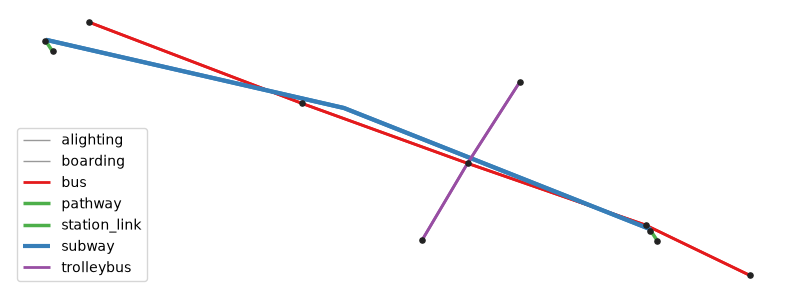

In [12]:
import matplotlib.pyplot as plt

EDGE_STYLE = {
    "subway": ("#377eb8", 3.0),
    "bus": ("#e41a1c", 2.0),
    "trolleybus": ("#984ea3", 2.0),
    "pathway": ("#4daf4a", 2.5),
    "station_link": ("#4daf4a", 2.5),
    "boarding": ("#999999", 1.0),
    "alighting": ("#999999", 1.0),
}

fig, ax = plt.subplots(figsize=(10, 6))
for edge_type, group in edges.groupby("type"):
    color, width = EDGE_STYLE.get(edge_type, ("#bdbdbd", 1.0))
    group.plot(ax=ax, color=color, linewidth=width, label=edge_type)
nodes = public_transport.nodes_gdf
nodes.loc[nodes["type"].isin(["platform", "station_platform", "station_entry_exit"])].plot(
    ax=ax, color="#222222", markersize=14, zorder=3
)
ax.legend(loc="lower left")
ax.set_axis_off()
plt.show()

## Join with the walking network

Build the walking graph first and pass its CRS to the GTFS builder, so both layers share one metric projection. `join_pt_walk_graph` then attaches platforms and station entrances to nearby walking edges.

In [13]:
from iduedu import get_walk_graph, join_pt_walk_graph

walk = get_walk_graph(osm_id=OSM_ID)
public_transport = get_gtfs_public_transport_graph(
    fused, service_date=SERVICE_DATE, start_time="07:00", end_time="10:00", crs=walk.crs
)
intermodal = join_pt_walk_graph(public_transport, walk, max_dist=50)
intermodal

2026-09-15 14:03:20.462 | WARNING  | Removing 330 nodes outside the largest connected component. Retaining 19802 of 20132 nodes.


UrbanGraph(nodes=19841, edges=26731, is_multigraph=True, is_directed=True, edge_direction_column='oneway', crs='EPSG:32636', type='intermodal')

## Route across the layers

Take the walking nodes nearest to a point by Primorskaya and a point on 1-ya Liniya, find the fastest route between them, and turn it into edges to see how the time splits between walking, waiting and riding.

In [14]:
import geopandas as gpd
from shapely.geometry import Point

from iduedu import path_to_edges, single_source_dijkstra_path

points = gpd.GeoSeries([Point(30.2330, 59.9490), Point(30.2860, 59.9410)], crs=4326).to_crs(intermodal.crs)
walk_nodes = intermodal.nodes_gdf.loc[intermodal.nodes_gdf["type"].isna()]
origin, destination = walk_nodes.index[walk_nodes.sindex.nearest(points)[1]]

path = single_source_dijkstra_path(intermodal, origin, destination, weight="time_min")
route = path_to_edges(intermodal, path)
print(f"travel time: {route['time_min'].sum():.1f} min")
route.groupby("type", sort=False)["time_min"].sum().round(1)

travel time: 21.4 min


type
walk            10.9
pathway          4.5
station_link     0.0
boarding         2.0
subway           4.0
alighting        0.0
Name: time_min, dtype: float64

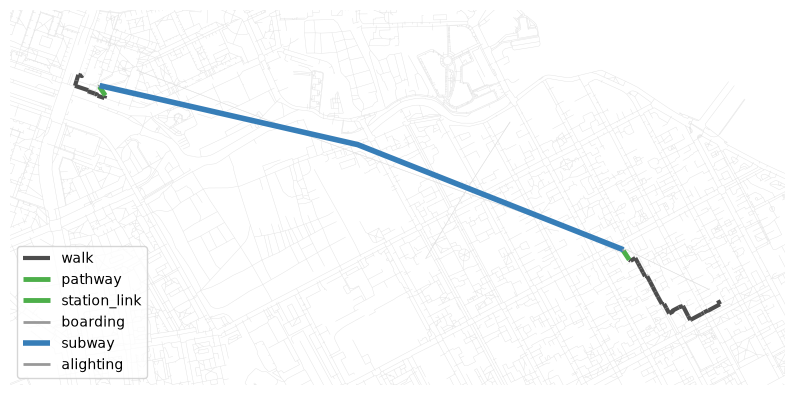

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
intermodal.edges_gdf.plot(ax=ax, color="#e0e0e0", linewidth=0.3)
for edge_type, group in route.groupby("type", sort=False):
    color, width = EDGE_STYLE.get(edge_type, ("#4d4d4d", 2.0))
    group.plot(ax=ax, color=color, linewidth=width + 1, label=edge_type)
xmin, ymin, xmax, ymax = route.total_bounds
ax.set_xlim(xmin - 300, xmax + 300)
ax.set_ylim(ymin - 300, ymax + 300)
ax.legend(loc="lower left")
ax.set_axis_off()
plt.show()